In [1]:
# cell 1: setup and loading data for preprocessing
import pandas as pd
import spacy
import os

print("loading datasets...")
# load the uncleaned data from stage 1
df_model_a = pd.read_csv('data/processed/model_a_train_uncleaned.csv')
df_model_b = pd.read_csv('data/processed/model_b_train_uncleaned.csv')
df_model_c = pd.read_csv('data/processed/model_c_train_uncleaned.csv')

print(f"model a size: {df_model_a.shape}")
print(f"model b size: {df_model_b.shape}")
print(f"model c size: {df_model_c.shape}")

# try to load english spacy model, download if missing
try:
    nlp = spacy.load("en_core_web_sm")
    print("spacy model 'en_core_web_sm' loaded successfully.")
except OSError:
    print("downloading spacy model...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")
    print("spacy model downloaded and loaded.")

loading datasets...
model a size: (39219, 2)
model b size: (18793, 11)
model c size: (6909, 2)
spacy model 'en_core_web_sm' loaded successfully.


In [2]:
# cell 2: core text cleaning function (regex + emojis)
import re
import emoji

def clean_text_basic(text):
    """
    performs basic text cleaning using regular expressions and demojizes emojis.
    """
    text = str(text).lower()
    
    # 0. convert emojis to words (e.g., 🤬 -> face_with_symbols_on_mouth)
    # using spaces as delimiters so the words blend naturally into the text
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    # 1. remove html tags (like <br /> from imdb)
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 2. remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 3. remove the [name] token specific to goemotions
    text = re.sub(r'\[name\]', '', text)
    
    # 4. remove all non-alphabetic characters (keeps only a-z)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 5. replace multiple spaces with a single space and strip edges
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# let's test it on a maliciously dirty string
dirty_sample = "OMG! <br /><br /> This movie is completely TRASH... 1/10. 🤬 [NAME] said it's good, but go to http://fake.url.com to see the truth! 123"
cleaned_sample = clean_text_basic(dirty_sample)

print("original:")
print(dirty_sample)
print("\ncleaned:")
print(cleaned_sample)

original:
OMG! <br /><br /> This movie is completely TRASH... 1/10. 🤬 [NAME] said it's good, but go to http://fake.url.com to see the truth! 123

cleaned:
omg this movie is completely trash face with symbols on mouth said it s good but go to to see the truth


In [3]:
# cell 3: tokenization, lemmatization, and smart stop-word removal
import spacy

# we use the 'nlp' object loaded in cell 1
# customize the stop words list to keep negations and important modifiers
exceptions = ['not', 'no', 'never', 'none', 'cannot', 'without', 'against', 'but', 'however', 'nothing']
for word in exceptions:
    nlp.vocab[word].is_stop = False

def lemmatize_and_remove_stopwords(text):
    """
    tokenizes, removes stop words (respecting exceptions), and lemmatizes the text.
    """
    # parse the text using spacy (this automatically tokenizes)
    doc = nlp(text)
    
    clean_tokens = []
    for token in doc:
        # filter out stop words and empty spaces
        if not token.is_stop and token.text.strip():
            # append the lemma of the token
            # '-PRON-' is a special lemma spacy used for pronouns in older versions, 
            # we ensure we just get the clean text or lowercase lemma
            clean_tokens.append(token.lemma_.lower())
            
    # join tokens back into a single string
    return " ".join(clean_tokens)

# let's test it on a tricky sentence
test_sentence = "i am not feeling very happy today, this is completely unacceptable!"
# simulate output from cell 2 (basic cleaning)
basic_cleaned = "i am not feeling very happy today this is completely unacceptable"

final_cleaned = lemmatize_and_remove_stopwords(basic_cleaned)

print("after basic cleaning (cell 2):")
print(basic_cleaned)
print("\nafter spacy processing (cell 3):")
print(final_cleaned)

after basic cleaning (cell 2):
i am not feeling very happy today this is completely unacceptable

after spacy processing (cell 3):
not feel happy today completely unacceptable


In [ ]:
# cell 4: full preprocessing pipeline and execution
from tqdm import tqdm
import os

# enable tqdm integration with pandas
tqdm.pandas()

def preprocess_text(text):
    """
    runs the complete text cleaning pipeline: 
    regex & emojis (cell 2) -> spacy lemmatization (cell 3)
    """
    basic_cleaned = clean_text_basic(text)
    final_cleaned = lemmatize_and_remove_stopwords(basic_cleaned)
    return final_cleaned

# process model c (formality) - usually the fastest
print("cleaning model c (formality)...")
df_model_c['clean_text'] = df_model_c['text'].progress_apply(preprocess_text)

# process model b (emotions)
print("\ncleaning model b (emotions)...")
df_model_b['clean_text'] = df_model_b['text'].progress_apply(preprocess_text)

# process model a (sentiment) - takes the longest due to imdb length
print("\ncleaning model a (sentiment) - this might take a few minutes...")
df_model_a['clean_text'] = df_model_a['text'].progress_apply(preprocess_text)

# drop any rows that became completely empty after cleaning 
# (e.g., if the original text was just a single stop-word or punctuation)
df_model_a = df_model_a[df_model_a['clean_text'].str.strip() != '']
df_model_b = df_model_b[df_model_b['clean_text'].str.strip() != '']
df_model_c = df_model_c[df_model_c['clean_text'].str.strip() != '']

# ensure processed directory exists
os.makedirs('data/processed', exist_ok=True)

# save the fully cleaned datasets
df_model_a.to_csv('data/processed/model_a_train_cleaned.csv', index=False)
df_model_b.to_csv('data/processed/model_b_train_cleaned.csv', index=False)
df_model_c.to_csv('data/processed/model_c_train_cleaned.csv', index=False)

print("\nall datasets cleaned and saved successfully!")

# display a comparison for model a
print("\nexample of cleaning (model a):")
sample = df_model_a.sample(1)
print("original:", sample['text'].values[0])
print("cleaned: ", sample['clean_text'].values[0])


cleaning model b (emotions)...


100%|██████████████████████████████████████████| 18781/18781 [01:07<00:00, 279.05it/s]



all datasets cleaned and saved successfully!


text length reduction analysis:
-----------------------------------
model a (sentiment):
  avg words (original): 154.2
  avg words (cleaned):  73.9
  reduction:            52.1%

model b (emotions):
  avg words (original): 13.0
  avg words (cleaned):  6.5
  reduction:            50.1%

model c (formality):
  avg words (original): 15.2
  avg words (cleaned):  7.9
  reduction:            47.9%



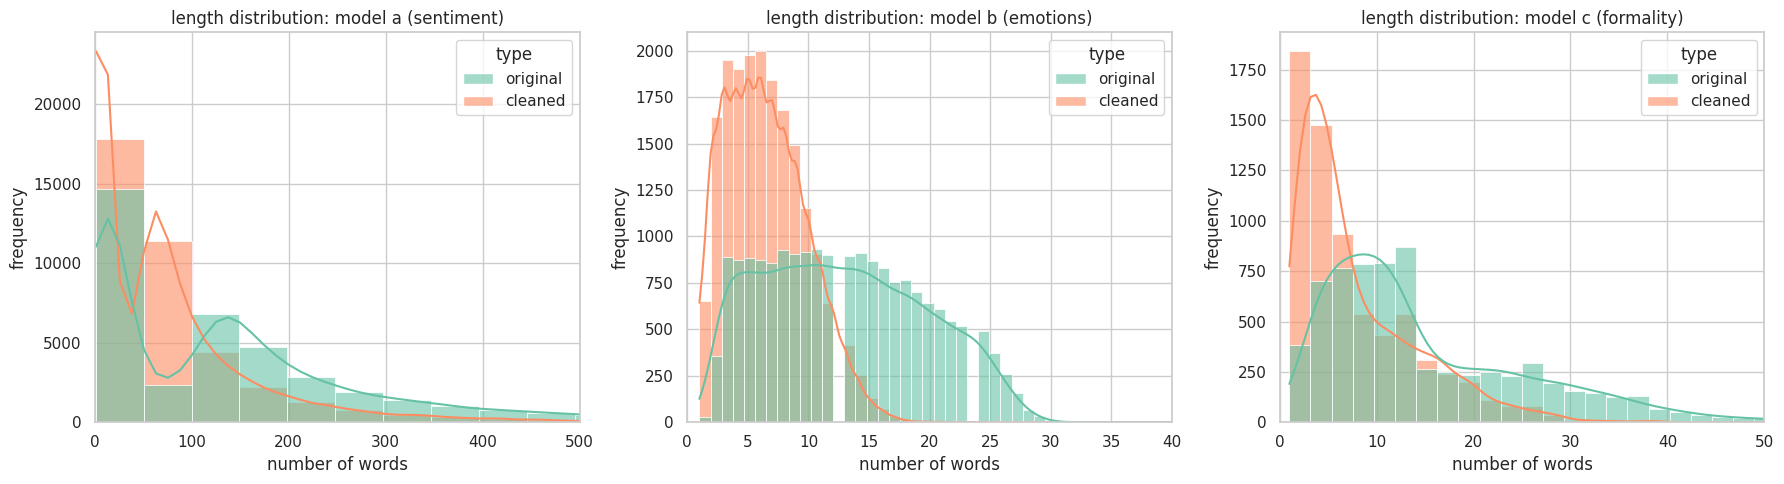

In [11]:
# cell 5: analyzing text length reduction and plotting distributions
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# list of tuples containing dataset names and their variables
datasets = [
    ('model a (sentiment)', df_model_a),
    ('model b (emotions)', df_model_b),
    ('model c (formality)', df_model_c)
]

print("text length reduction analysis:\n" + "-"*35)

# calculate lengths and print stats
for name, df in datasets:
    df['orig_len'] = df['text'].astype(str).apply(lambda x: len(x.split()))
    df['clean_len'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))
    
    orig_mean = df['orig_len'].mean()
    clean_mean = df['clean_len'].mean()
    reduction = (1 - clean_mean / orig_mean) * 100
    
    print(f"{name}:")
    print(f"  avg words (original): {orig_mean:.1f}")
    print(f"  avg words (cleaned):  {clean_mean:.1f}")
    print(f"  reduction:            {reduction:.1f}%\n")

# plot distributions
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, df) in enumerate(datasets):
    # prepare data for plotting
    plot_data = pd.DataFrame({
        'length': pd.concat([df['orig_len'], df['clean_len']]),
        'type': ['original'] * len(df) + ['cleaned'] * len(df)
    })
    
    sns.histplot(data=plot_data, x='length', hue='type', bins=50, kde=True, ax=axes[i], palette='Set2', alpha=0.6)
    axes[i].set_title(f'length distribution: {name}', fontsize=12)
    axes[i].set_xlabel('number of words')
    axes[i].set_ylabel('frequency')
    
    # limit x-axis to cut off long tails for better visualization
    if 'model a' in name:
        axes[i].set_xlim(0, 500)
    elif 'model b' in name:
        axes[i].set_xlim(0, 40)
    else:
        axes[i].set_xlim(0, 50)

plt.tight_layout()
plt.show()

# drop the temporary length columns to keep dataframes clean
for _, df in datasets:
    df.drop(columns=['orig_len', 'clean_len'], inplace=True, errors='ignore')

generating comparison for 'joy'...


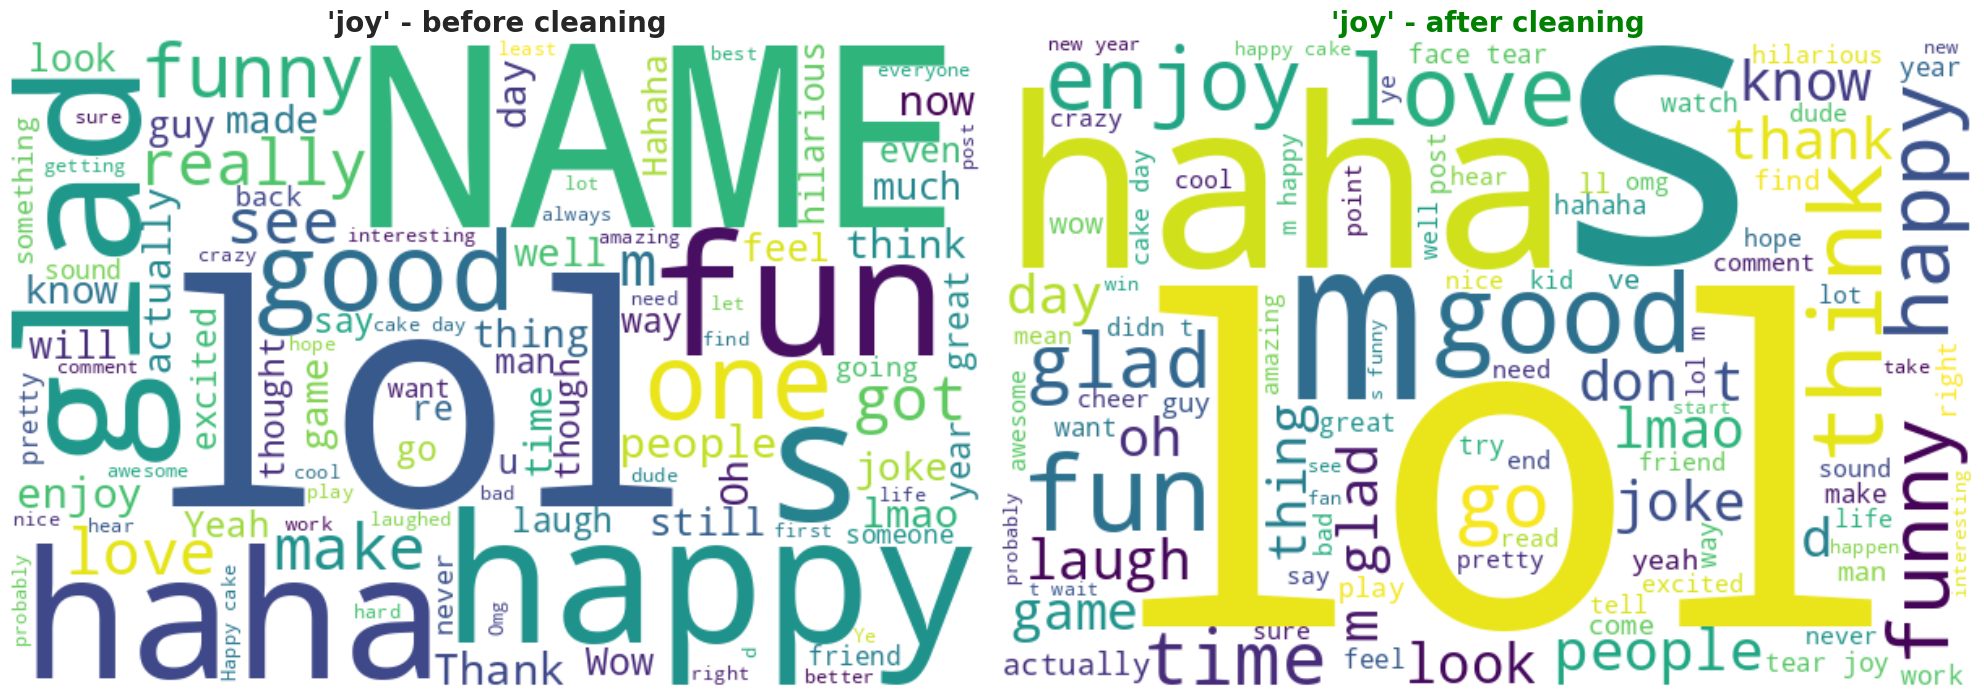

generating comparison for 'anger'...


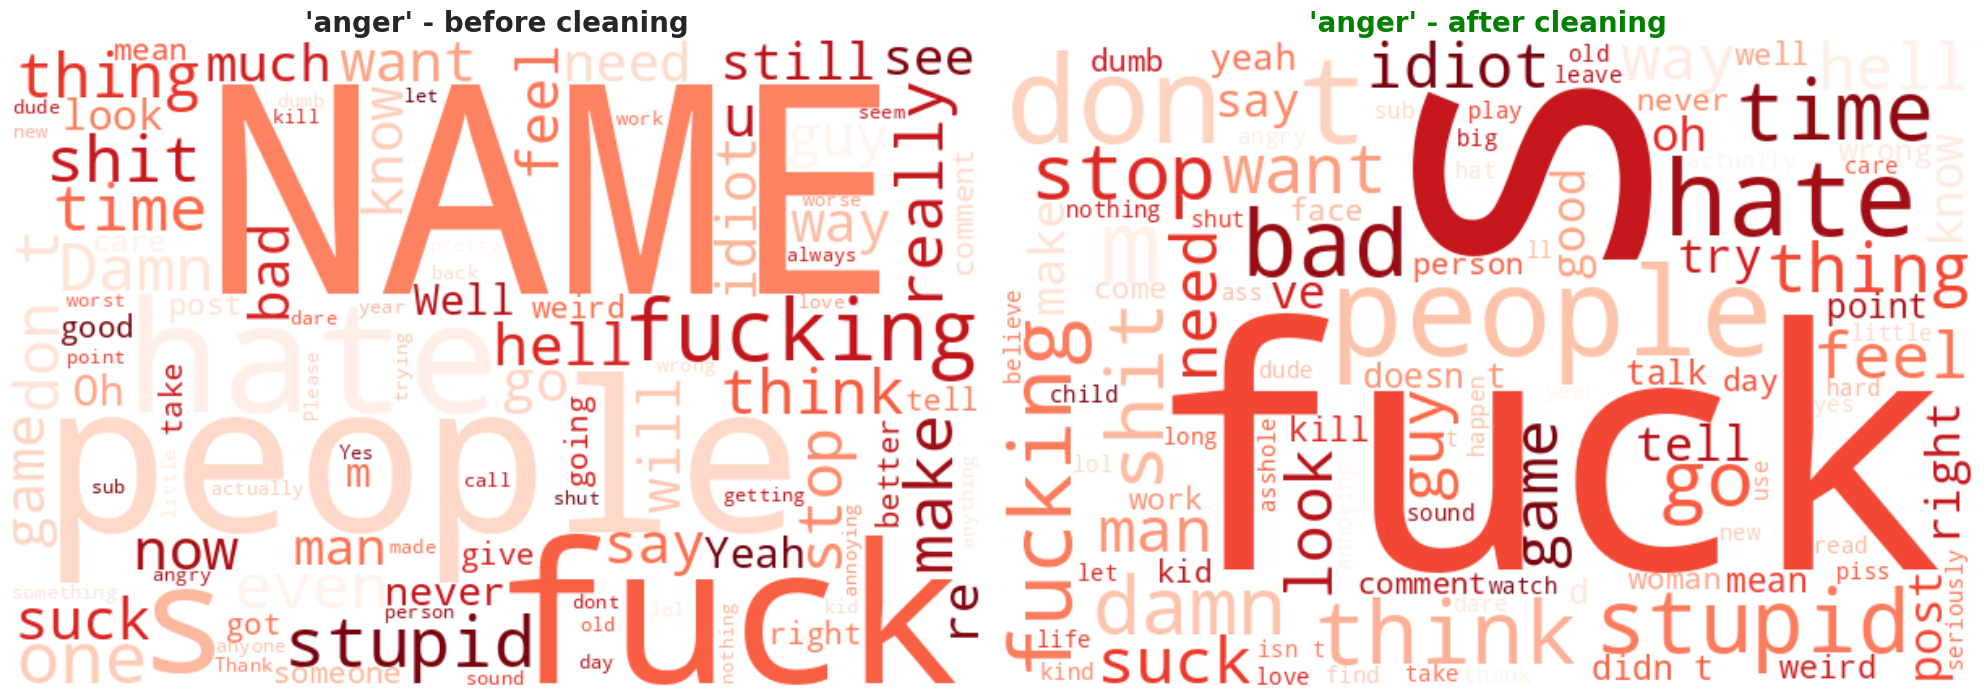

In [13]:
# cell 6: side-by-side wordcloud comparison (before vs after) for model b
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

# function to generate a single wordcloud object
def generate_wordcloud(data_frame, column_name, emotion_name, color_map):
    # filter texts that belong to the specified emotion
    texts = data_frame[data_frame[emotion_name] == 1][column_name].dropna().values
    
    # combine all texts into one giant string
    combined_text = ' '.join(str(text) for text in texts)
    
    # generate and return the wordcloud object
    return WordCloud(width=600, height=400, 
                     background_color='white', 
                     colormap=color_map, 
                     max_words=100).generate(combined_text)

# function to plot two wordclouds side-by-side
def plot_comparison(emotion_name, color_map):
    print(f"generating comparison for '{emotion_name}'...")
    
    # 1. generate 'before' wordcloud (raw text)
    wc_before = generate_wordcloud(df_model_b, 'text', emotion_name, color_map)
    
    # 2. generate 'after' wordcloud (cleaned text)
    wc_after = generate_wordcloud(df_model_b, 'clean_text', emotion_name, color_map)
    
    # 3. plot them side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # left plot: before
    axes[0].imshow(wc_before, interpolation='bilinear')
    axes[0].set_title(f"'{emotion_name}' - before cleaning", fontsize=20, fontweight='bold')
    axes[0].axis('off')
    
    # right plot: after
    axes[1].imshow(wc_after, interpolation='bilinear')
    axes[1].set_title(f"'{emotion_name}' - after cleaning", fontsize=20, fontweight='bold', color='green')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# run the comparison for 'joy'
plot_comparison('joy', 'viridis')

# run the comparison for 'anger'
plot_comparison('anger', 'Reds')

### preprocessing conclusions

**1. length reduction:**
the cleaning pipeline successfully reduced the volume of noise. model a saw a massive reduction in word count due to the removal of html tags and heavy stop-words. models b and c also became more condensed.

**2. semantic clarity:**
the wordclouds confirm that the core emotional signals are now much stronger. 'name' tokens and generic stop-words were successfully removed. the remaining artifacts (isolated letters like 's', 'm', 've' from stripped apostrophes) will be downweighted by tf-idf in the next stage and do not pose a threat to basic ml algorithms.

**3. readiness:**
all three datasets are normalized and ready for vectorization and baseline modeling.